In [91]:
#импорт библиотеки
import pandas as pd
import matplotlib.pyplot as plt

In [92]:
#загр датасет
df = pd.read_csv(
    "spamhamdata.csv",
    sep="\t",
    header=None,
    names=["label", "text"] #задаем столбцы
)

In [93]:
#проверяем
df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [94]:
#размер
df.shape

(5572, 2)

In [95]:
#проверяем класы
df["label"].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

In [96]:
#типы данных
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   5572 non-null   object
 1   text    5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [97]:
#проверка пропусков
df.isnull().sum()

label    0
text     0
dtype: int64

In [98]:
#проверка дублей
df.duplicated().sum()

np.int64(403)

In [99]:
#визуально смотрим каждый класс
df[df["label"] == "spam"]["text"].head(10)

2     Free entry in 2 a wkly comp to win FA Cup fina...
5     FreeMsg Hey there darling it's been 3 week's n...
8     WINNER!! As a valued network customer you have...
9     Had your mobile 11 months or more? U R entitle...
11    SIX chances to win CASH! From 100 to 20,000 po...
12    URGENT! You have won a 1 week FREE membership ...
15    XXXMobileMovieClub: To use your credit, click ...
19    England v Macedonia - dont miss the goals/team...
34    Thanks for your subscription to Ringtone UK yo...
42    07732584351 - Rodger Burns - MSG = We tried to...
Name: text, dtype: object

In [100]:
df[df["label"] == "ham"]["text"].head(10)

0     Go until jurong point, crazy.. Available only ...
1                         Ok lar... Joking wif u oni...
3     U dun say so early hor... U c already then say...
4     Nah I don't think he goes to usf, he lives aro...
6     Even my brother is not like to speak with me. ...
7     As per your request 'Melle Melle (Oru Minnamin...
10    I'm gonna be home soon and i don't want to tal...
13    I've been searching for the right words to tha...
14                  I HAVE A DATE ON SUNDAY WITH WILL!!
16                           Oh k...i'm watching here:)
Name: text, dtype: object

In [101]:
#длина сообщ
df["text_length"] = df["text"].str.len()
df[["label", "text", "text_length"]].head()

,label,text,text_length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


In [102]:
df[df.duplicated(keep=False)].sort_values("text").head(20)

,label,text,text_length
505,spam,+123 Congratulations - in this week's competit...,169
2124,spam,+123 Congratulations - in this week's competit...,169
2344,ham,1) Go to write msg 2) Put on Dictionary mode 3...,141
1373,ham,1) Go to write msg 2) Put on Dictionary mode 3...,141
2163,ham,1) Go to write msg 2) Put on Dictionary mode 3...,141
1050,spam,18 days to Euro2004 kickoff! U will be kept in...,135
2719,spam,18 days to Euro2004 kickoff! U will be kept in...,135
2044,spam,4mths half price Orange line rental & latest c...,155
389,spam,4mths half price Orange line rental & latest c...,155
1779,ham,7 wonders in My WORLD 7th You 6th Ur style 5th...,151


In [103]:
df_clean = df.drop_duplicates().copy()

df_clean.shape

(5169, 3)

In [104]:
df_clean["label"].value_counts()

label
ham     4516
spam     653
Name: count, dtype: int64

In [105]:
#баланс классов
df_clean["label"].value_counts(normalize=True) * 100

label
ham     87.366996
spam    12.633004
Name: proportion, dtype: float64

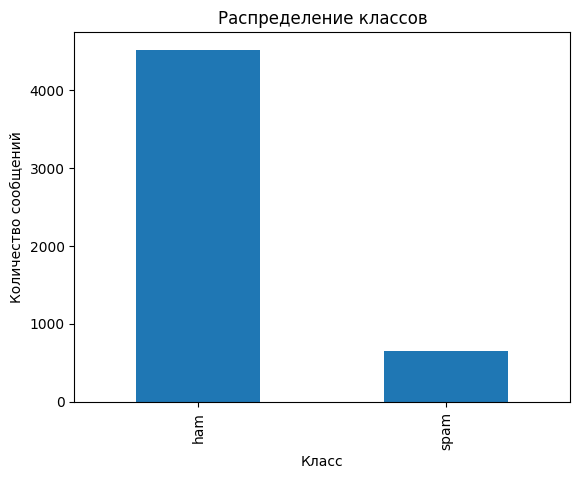

In [106]:
df_clean["label"].value_counts().plot(kind="bar")

plt.title("Распределение классов")
plt.xlabel("Класс")
plt.ylabel("Количество сообщений")
plt.show()

In [107]:
df_clean["text_length"] = df_clean["text"].str.len()
df_clean[["label", "text_length"]].head()

,label,text_length
0,ham,111
1,ham,29
2,spam,155
3,ham,49
4,ham,61


In [108]:
df_clean.groupby("label")["text_length"].mean()

label
ham      70.906333
spam    137.704441
Name: text_length, dtype: float64

In [109]:
%pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


In [110]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [111]:
text = " ".join(df_clean["text"])

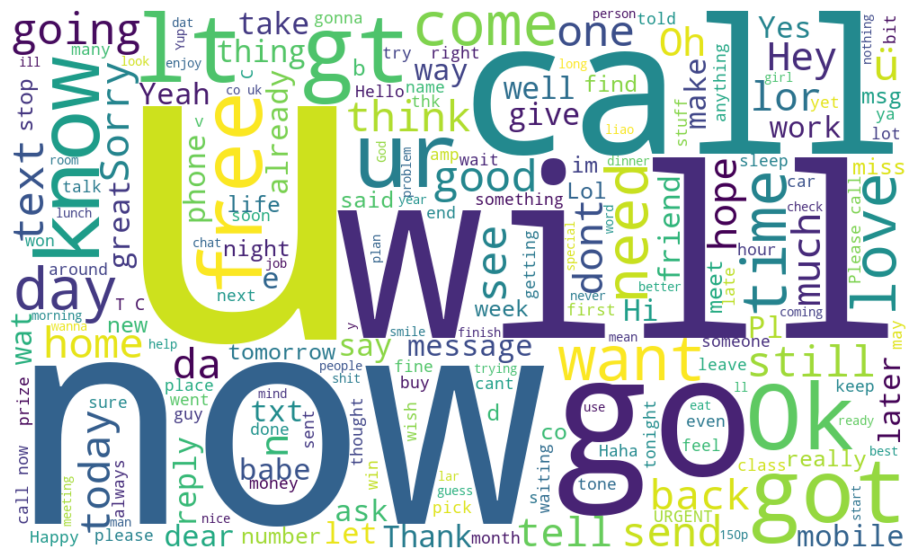

In [112]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(
    width=1000,
    height=600,
    background_color="white"
).generate(text)

plt.figure(figsize=(12, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

In [113]:
from wordcloud import STOPWORDS

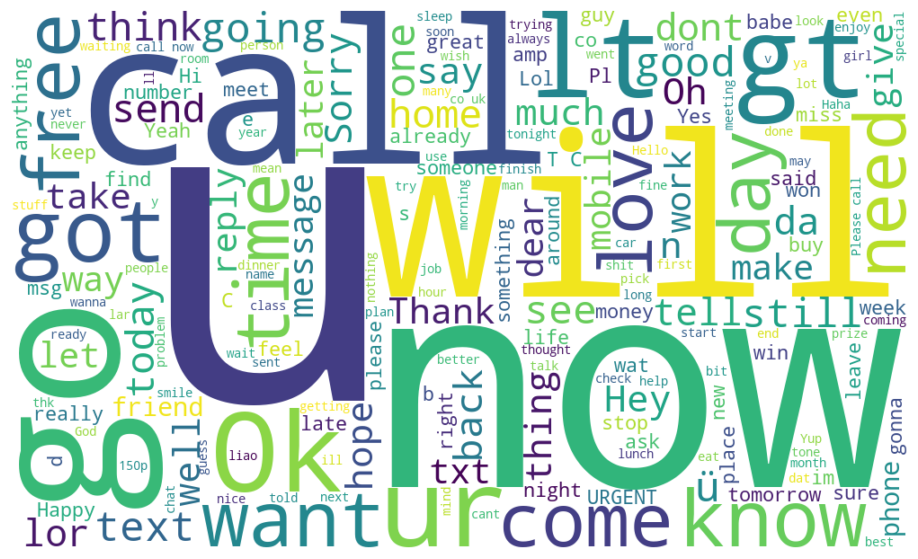

In [114]:
wordcloud = WordCloud(
    width=1000,
    height=600,
    background_color="white",
    stopwords=STOPWORDS
).generate(text)

plt.figure(figsize=(12, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

In [115]:
text = " ".join(df_clean["text"])

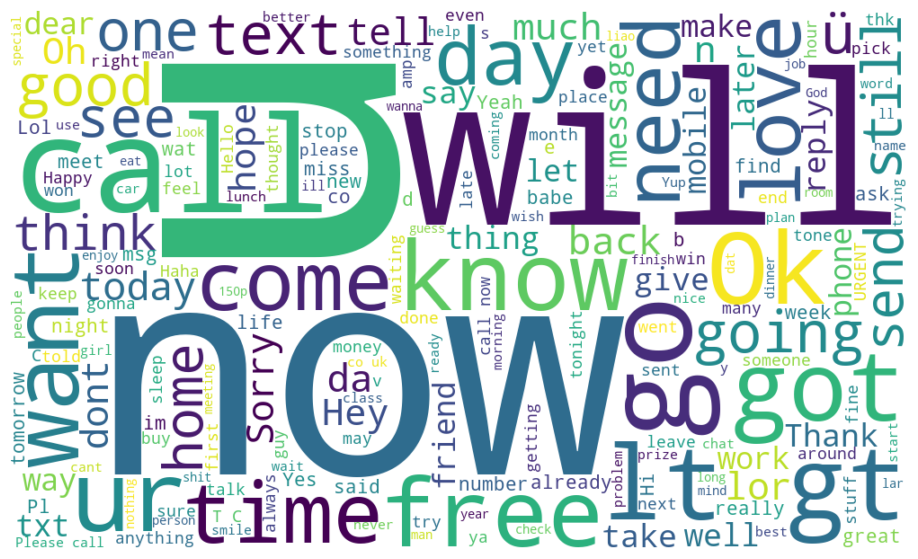

In [116]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(
    width=1000,
    height=600,
    background_color="white"
).generate(text)

plt.figure(figsize=(12, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

In [117]:
from wordcloud import STOPWORDS

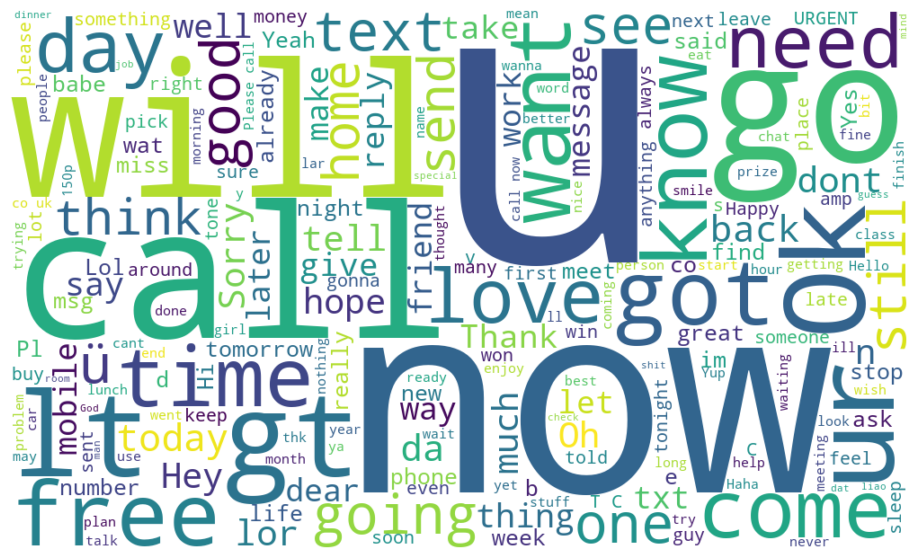

In [118]:
wordcloud = WordCloud(
    width=1000,
    height=600,
    background_color="white",
    stopwords=STOPWORDS
).generate(text)

plt.figure(figsize=(12, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

In [119]:
import numpy as np
from PIL import Image, ImageDraw

In [120]:
mask_image = Image.new("L", (1000, 700), 255)
draw = ImageDraw.Draw(mask_image)

In [121]:
# тело
draw.ellipse((250, 220, 750, 500), fill=0)

# голова
draw.ellipse((680, 180, 850, 360), fill=0)

# ухо
draw.ellipse((790, 190, 900, 270), fill=0)

# ноги
draw.rectangle((350, 450, 410, 620), fill=0)
draw.rectangle((480, 450, 540, 620), fill=0)
draw.rectangle((650, 450, 710, 620), fill=0)

# хвост
draw.ellipse((180, 250, 300, 350), fill=0)

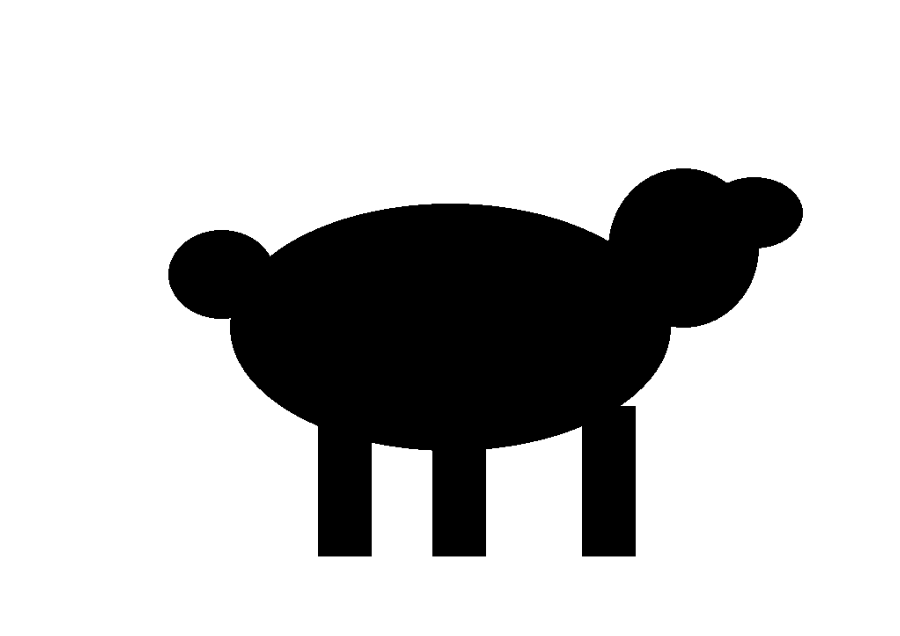

In [122]:
plt.figure(figsize=(12, 8))
plt.imshow(mask_image, cmap="gray")
plt.axis("off")
plt.show()

In [123]:
mask = np.array(mask_image)

In [124]:
wordcloud_sheep = WordCloud(
    width=1000,
    height=700,
    background_color="white",
    stopwords=STOPWORDS,
    mask=mask,
    contour_width=2
).generate(text)

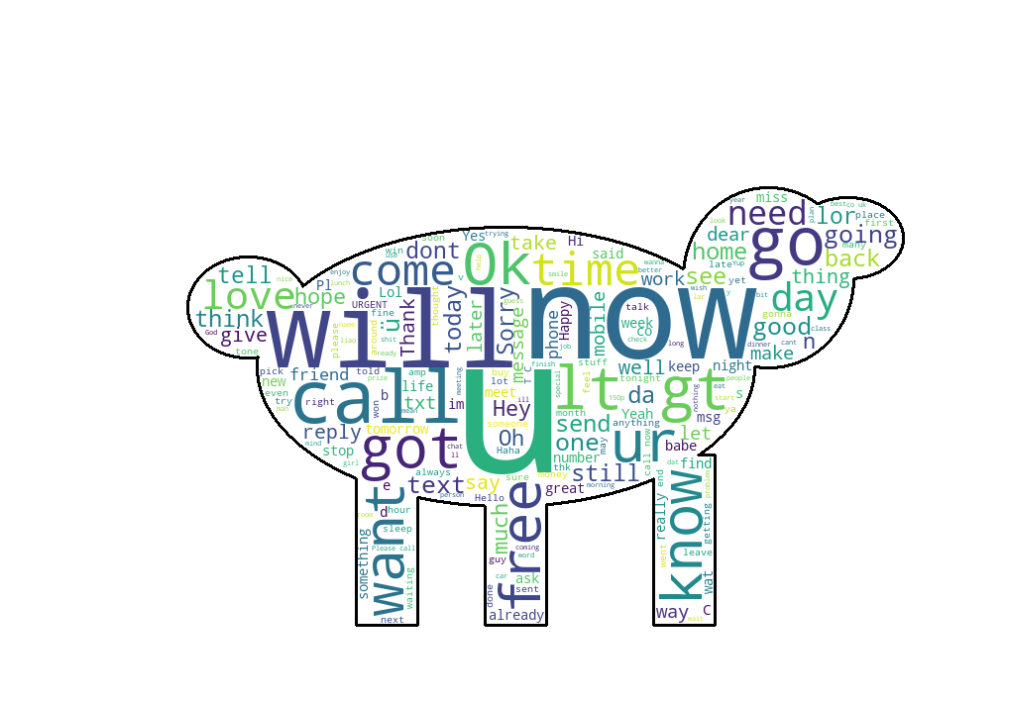

In [125]:
plt.figure(figsize=(14, 9))
plt.imshow(wordcloud_sheep, interpolation="bilinear")
plt.axis("off")
plt.show()

In [126]:
X = df_clean["text"]
y = df_clean["label"]

In [127]:
#делим данные
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [128]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [129]:
X_train_tfidf.shape

(4135, 7680)

In [130]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()

nb.fit(X_train_tfidf, y_train)

MultinomialNB()

In [131]:
y_pred = nb.predict(X_test_tfidf)

In [132]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9526112185686654


In [133]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         ham       0.95      1.00      0.97       903
        spam       1.00      0.63      0.77       131

    accuracy                           0.95      1034
   macro avg       0.97      0.81      0.87      1034
weighted avg       0.96      0.95      0.95      1034



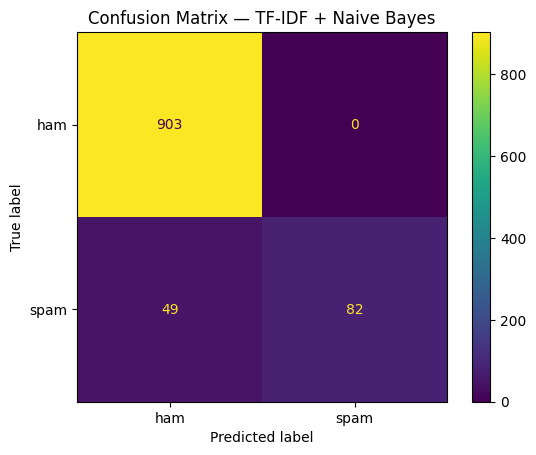

In [134]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.title("Confusion Matrix — TF-IDF + Naive Bayes")
plt.show()

In [135]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         ham       0.95      1.00      0.97       903
        spam       1.00      0.63      0.77       131

    accuracy                           0.95      1034
   macro avg       0.97      0.81      0.87      1034
weighted avg       0.96      0.95      0.95      1034



In [136]:
%pip install rank-bm25

Note: you may need to restart the kernel to use updated packages.


In [137]:
from rank_bm25 import BM25Okapi

In [138]:
def tokenize(text):
    return text.lower().split()

train_tokens = [tokenize(text) for text in X_train]
test_tokens = [tokenize(text) for text in X_test]

In [139]:
train_tokens[0]

['ta-daaaaa!', 'i', 'am', 'home', 'babe,', 'are', 'you', 'still', 'up', '?']

In [140]:
from collections import Counter

vocab = sorted(set(word for doc in train_tokens for word in doc))

len(vocab)

11778

In [141]:
bm25 = BM25Okapi(train_tokens)

In [142]:
sample_size = 500

reference_tokens = train_tokens[:sample_size]
reference_labels = y_train.iloc[:sample_size].values

In [143]:
bm25 = BM25Okapi(reference_tokens)

In [144]:
X_train_bm25 = np.array([
    bm25.get_scores(tokens)
    for tokens in train_tokens
])

In [145]:
X_test_bm25 = np.array([
    bm25.get_scores(tokens)
    for tokens in test_tokens
])

In [146]:
X_train_bm25.shape

(4135, 500)

In [147]:
X_test_bm25.shape

(1034, 500)

In [148]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(
    n_neighbors=5,
    metric="cosine"
)

In [149]:
knn.fit(X_train_bm25, y_train)

KNeighborsClassifier(metric='cosine')

In [150]:
y_pred_knn = knn.predict(X_test_bm25)

In [151]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

         ham       0.98      0.98      0.98       903
        spam       0.89      0.83      0.86       131

    accuracy                           0.97      1034
   macro avg       0.93      0.91      0.92      1034
weighted avg       0.96      0.97      0.96      1034



In [152]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_knn))

Accuracy: 0.965183752417795


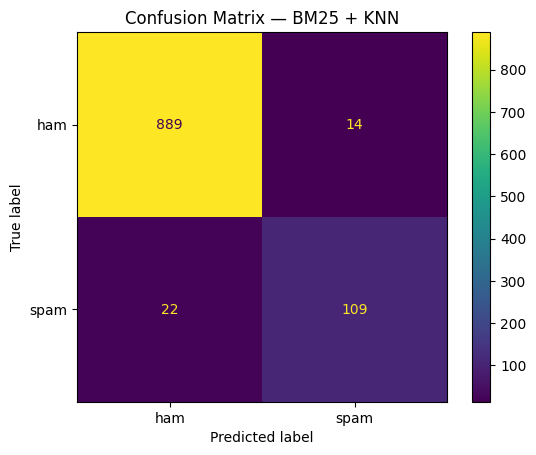

In [153]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_knn
)

plt.title("Confusion Matrix — BM25 + KNN")
plt.show()

In [154]:
%pip install fasttext

Note: you may need to restart the kernel to use updated packages.


In [155]:
import fasttext

print("FastText работает!")

FastText работает!


In [156]:
with open("fasttext_train.txt", "w", encoding="utf-8") as f:
    for label, text in zip(y_train, X_train):
        text = str(text).replace("\n", " ")
        f.write(f"__label__{label} {text}\n")

print("Файл создан")

Файл создан


In [157]:
with open("fasttext_train.txt", "r", encoding="utf-8") as f:
    lines = f.readlines()

print("Количество строк:", len(lines))
print(lines[:2])

Количество строк: 4137
['__label__ham Ta-Daaaaa! I am home babe, are you still up ?\n', '__label__ham Yup having my lunch buffet now.. U eat already?\n']


In [158]:
model_ft = fasttext.train_supervised(
    input="fasttext_train.txt",
    epoch=25,
    lr=0.5,
    wordNgrams=2
)

Read 0M words
Number of words:  13596
Number of labels: 2
Progress: 100.0% words/sec/thread:  835473 lr:  0.000000 avg.loss:  0.011829 ETA:   0h 0m 0s


In [3]:
model_ft = fasttext.train_supervised(
    input="fasttext_train.txt",
    epoch=25,
    lr=0.5,
    wordNgrams=2
)

Read 0M words
Number of words:  13596
Number of labels: 2
Progress: 100.0% words/sec/thread:  834574 lr:  0.000000 avg.loss:  0.011702 ETA:   0h 0m 0s


In [2]:
import pandas as pd

df = pd.read_csv(
    "spamhamdata.csv",
    sep="\t",
    header=None,
    names=["label", "text"]
)

print(df.shape)
print(df.head())

(5572, 2)
  label                                               text
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [3]:
df_clean = df.drop_duplicates().copy()

X = df_clean["text"]
y = df_clean["label"]

print("Размер:", df_clean.shape)
print("\nКлассы:")
print(y.value_counts())

Размер: (5169, 2)

Классы:
label
ham     4516
spam     653
Name: count, dtype: int64


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", len(X_train))
print("Test:", len(X_test))

Train: 4135
Test: 1034


In [11]:
with open("fasttext_test.txt", "w", encoding="utf-8") as f:
    for label, text in zip(y_test, X_test):
        text = str(text).replace("\n", " ")
        f.write(f"__label__{label} {text}\n")

print("Тестовый файл создан")

Тестовый файл создан


In [12]:
print(model_ft)

In [13]:
y_pred_ft = []

for text in X_test:
    labels, probabilities = model_ft.predict(str(text))
    y_pred_ft.append(labels[0].replace("__label__", ""))

print("Предсказаний:", len(y_pred_ft))

Предсказаний: 1034


In [14]:
from sklearn.metrics import classification_report, accuracy_score

print(classification_report(y_test, y_pred_ft))
print("Accuracy:", accuracy_score(y_test, y_pred_ft))

              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       903
        spam       0.97      0.85      0.91       131

    accuracy                           0.98      1034
   macro avg       0.97      0.93      0.95      1034
weighted avg       0.98      0.98      0.98      1034

Accuracy: 0.9777562862669246


In [15]:
%pip install transformers torch

  Using cached pyyaml-6.0.3-cp39-cp39-macosx_11_0_arm64.whl.metadata (2.4 kB)
  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached urllib3-2.6.3-py3-none-any.whl.metadata (6.9 kB)
  Using cached certifi-2026.7.22-py3-none-any.whl.metadata (2.5 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 950.1 kB/s  0:00:12 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 223.2 kB/s  0:00:01eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 852.8 kB/s  0:00:05 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 1.1 MB/s  0:00:02 eta 0:00:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.6/73.6 MB 1.4 MB/s  0:00:52m0:00:0100:02
Using cached pyyaml-6.0.3-cp39-cp39-macosx_11_0_arm64.whl (174 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 1.2 MB/s  0:00:05 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.2/536.2 kB 1.1 MB/s 

In [5]:
import torch
import transformers

print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)

PyTorch: 2.8.0
Transformers: 4.57.6


In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")


Токенизатор BERT загружен


In [7]:
train_encodings = tokenizer(
    X_train.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    X_test.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

print("Train:", len(train_encodings["input_ids"]))
print("Test:", len(test_encodings["input_ids"]))
print("Длина одного сообщения:", len(train_encodings["input_ids"][0]))

Train: 4135
Test: 1034
Длина одного сообщения: 128


In [10]:
import torch
from torch.utils.data import Dataset

class SpamDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

In [11]:
label_map = {"ham": 0, "spam": 1}

y_train_num = y_train.map(label_map).tolist()
y_test_num = y_test.map(label_map).tolist()

print(y_train_num[:5])
print(y_test_num[:5])

[0, 0, 0, 0, 0]
[0, 0, 0, 0, 0]


In [14]:
print("Train:")
print("Ham:", y_train_num.count(0))
print("Spam:", y_train_num.count(1))

print("\nTest:")
print("Ham:", y_test_num.count(0))
print("Spam:", y_test_num.count(1))

Train:
Ham: 3613
Spam: 522

Test:
Ham: 903
Spam: 131


In [15]:
import torch
from torch.utils.data import Dataset

class SpamDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)


train_dataset = SpamDataset(train_encodings, y_train_num)
test_dataset = SpamDataset(test_encodings, y_test_num)

print("Train:", len(train_dataset))
print("Test:", len(test_dataset))

Train: 4135
Test: 1034


In [16]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))

Train batches: 517
Test batches: 65


In [18]:
from transformers import BertModel
import torch.nn as nn

class BERT_FNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.bert = BertModel.from_pretrained("bert-base-uncased")

        self.classifier = nn.Sequential(
            nn.Linear(768, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 2)
        )

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        cls_output = outputs.last_hidden_state[:, 0, :]

        return self.classifier(cls_output)



In [20]:
model_bert_fnn = BERT_FNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model_bert_fnn.parameters(),
    lr=2e-5
)

print("Модель на:", device)
print("Оптимизатор готов")

Модель на: mps
Оптимизатор готов


In [21]:
for epoch in range(2):
    model_bert_fnn.train()
    total_loss = 0

    for batch in train_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        outputs = model_bert_fnn(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    average_loss = total_loss / len(train_loader)

    print(
        f"Epoch {epoch + 1}/2 | "
        f"Loss: {average_loss:.4f}"
    )

Epoch 1/2 | Loss: 0.0747
Epoch 2/2 | Loss: 0.0222


In [22]:
from sklearn.metrics import classification_report, accuracy_score

model_bert_fnn.eval()

predictions = []
true_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model_bert_fnn(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        preds = torch.argmax(outputs, dim=1)

        predictions.extend(preds.cpu().tolist())
        true_labels.extend(labels.cpu().tolist())

print(classification_report(
    true_labels,
    predictions,
    target_names=["ham", "spam"]
))

print("Accuracy:", accuracy_score(true_labels, predictions))

              precision    recall  f1-score   support

         ham       0.99      1.00      0.99       903
        spam       0.98      0.92      0.95       131

    accuracy                           0.99      1034
   macro avg       0.99      0.96      0.97      1034
weighted avg       0.99      0.99      0.99      1034

Accuracy: 0.988394584139265


In [23]:
%pip install xgboost

Python(85827) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd

df = pd.read_csv(
    "spamhamdata.csv",
    sep="\t",
    header=None,
    names=["label", "text"]
)

df_clean = df.drop_duplicates().copy()

print("Размер данных:", df_clean.shape)

Размер данных: (5169, 2)


In [2]:
from sklearn.model_selection import train_test_split

X = df_clean["text"]
y = df_clean["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", len(X_train))
print("Test:", len(X_test))

Train: 4135
Test: 1034


In [4]:
import torch
from transformers import AutoTokenizer, BertModel

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
bert = BertModel.from_pretrained("bert-base-uncased")

device = torch.device(
    "mps" if torch.backends.mps.is_available() else "cpu"
)

bert = bert.to(device)
bert.eval()

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSdpaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False

In [5]:
train_encodings = tokenizer(
    X_train.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    X_test.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

print("Train:", len(train_encodings["input_ids"]))
print("Test:", len(test_encodings["input_ids"]))
print("Длина сообщения:", len(train_encodings["input_ids"][0]))

Train: 4135
Test: 1034
Длина сообщения: 128


In [6]:
from torch.utils.data import DataLoader, TensorDataset
import torch

def get_bert_embeddings(encodings):
    dataset = TensorDataset(
        torch.tensor(encodings["input_ids"]),
        torch.tensor(encodings["attention_mask"])
    )

    loader = DataLoader(
        dataset,
        batch_size=16,
        shuffle=False
    )

    embeddings = []

    with torch.no_grad():
        for input_ids, attention_mask in loader:
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)

            outputs = bert(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            cls_embeddings = outputs.last_hidden_state[:, 0, :]
            embeddings.append(cls_embeddings.cpu())

    return torch.cat(embeddings).numpy()


X_train_bert = get_bert_embeddings(train_encodings)
X_test_bert = get_bert_embeddings(test_encodings)

print("Train:", X_train_bert.shape)
print("Test:", X_test_bert.shape)

Train: (4135, 768)
Test: (1034, 768)


In [8]:
from xgboost import XGBClassifier

label_map = {"ham": 0, "spam": 1}

y_train_num = y_train.map(label_map)
y_test_num = y_test.map(label_map)

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(
    X_train_bert,
    y_train_num
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [9]:
from sklearn.metrics import classification_report, accuracy_score

y_pred_xgb = xgb_model.predict(X_test_bert)

print(classification_report(
    y_test_num,
    y_pred_xgb,
    target_names=["ham", "spam"]
))

print("Accuracy:", accuracy_score(y_test_num, y_pred_xgb))

              precision    recall  f1-score   support

         ham       0.99      1.00      0.99       903
        spam       0.99      0.91      0.95       131

    accuracy                           0.99      1034
   macro avg       0.99      0.95      0.97      1034
weighted avg       0.99      0.99      0.99      1034

Accuracy: 0.9874274661508704
